# EDA

In [24]:
from data_loader import data_loader

data = data_loader()

print(data)

       Month  Quantity  CompetitorQuantity  PromotionAmount  Construction  \
0    2015-01    346968        1.769949e+06     3.299285e+09   1291.666667   
1    2015-02    506905        1.184596e+06     2.889267e+09   1291.666667   
2    2015-03    237761        2.520689e+06     3.373951e+09   1291.666667   
3    2015-04    457745        2.971660e+06     1.912420e+09   1291.666667   
4    2015-05    415938        4.013159e+06     2.374965e+09   1291.666667   
..       ...       ...                 ...              ...           ...   
115  2024-08    278403        1.766198e+06     7.114821e+10   5512.395726   
116  2024-09    303710        1.580258e+06     6.643073e+10   4985.273209   
117  2024-10    329541        2.627782e+06     8.052215e+10   4598.845269   
118  2024-11    377284        1.892865e+06     1.124868e+11   4505.941326   
119  2024-12    302241        2.720679e+06     2.961404e+11   4253.551109   

          CPI       Exports       Imports       IPI  RegisteredFDI  \
0    

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Month               120 non-null    object 
 1   Quantity            120 non-null    int64  
 2   CompetitorQuantity  120 non-null    float64
 3   PromotionAmount     120 non-null    float64
 4   Construction        120 non-null    float64
 5   CPI                 120 non-null    float64
 6   Exports             120 non-null    float64
 7   Imports             120 non-null    float64
 8   IPI                 120 non-null    float64
 9   RegisteredFDI       120 non-null    float64
 10  DisbursedFDI        120 non-null    float64
 11  RetailSales         120 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 11.4+ KB


In [26]:
data.describe()

,Quantity,CompetitorQuantity,PromotionAmount,Construction,CPI,Exports,Imports,IPI,RegisteredFDI,DisbursedFDI,RetailSales
count,120.000000,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,349023.175000,2.300289e+06,3.266762e+10,4241.760969,0.646478,32066.599098,27894.405693,2.254082,3.253447,2.094137,625765.219030
std,74673.364793,8.333348e+05,4.820040e+10,3147.245283,0.451223,3380.510901,1856.019507,3.763218,1.103223,0.532827,154159.482117
min,223131.000000,1.052940e+06,1.243642e+09,648.833333,-0.230000,24076.502357,23677.631245,-5.436702,1.410000,1.200000,357923.000000
25%,295639.250000,1.646616e+06,4.110312e+09,1834.325297,0.315463,29862.422486,26702.466193,-0.448446,2.355780,1.678462,504565.750000
50%,333286.500000,2.164492e+06,1.408029e+10,3347.424706,0.685532,32286.183933,27890.001785,2.393269,3.140161,2.051161,598862.312221
75%,397813.750000,2.807305e+06,3.815695e+10,5526.709802,0.978462,34238.238799,29014.216971,4.667220,4.067147,2.503792,740105.132237
max,506905.000000,4.281098e+06,2.961404e+11,12862.094152,1.869000,39507.614618,32189.000000,10.049131,5.800177,3.402721,976034.109097


In [27]:
import matplotlib.pyplot as plt
import pandas as pd

data["Month"] = pd.to_datetime(data["Month"], format="%Y-%m")
columns = data.columns[1:]

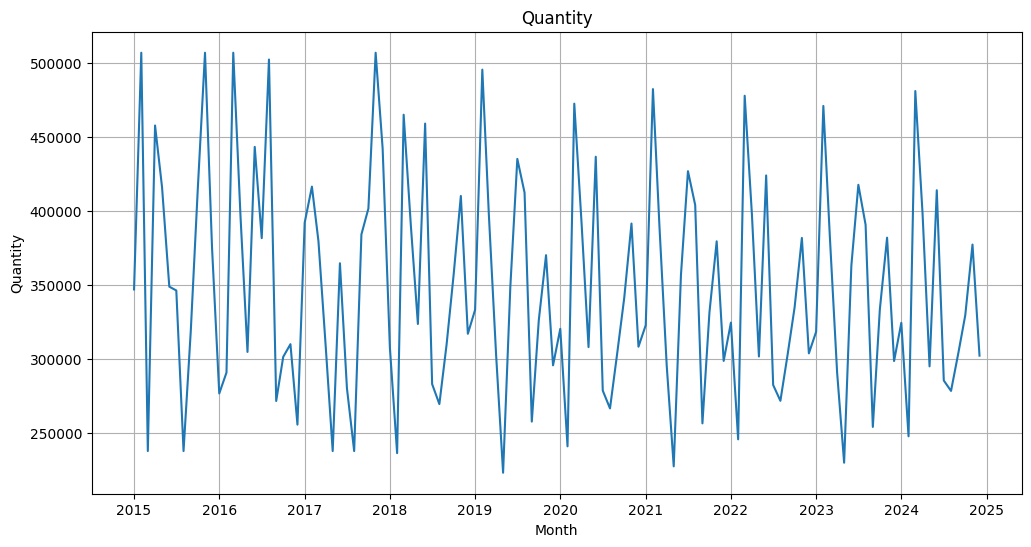

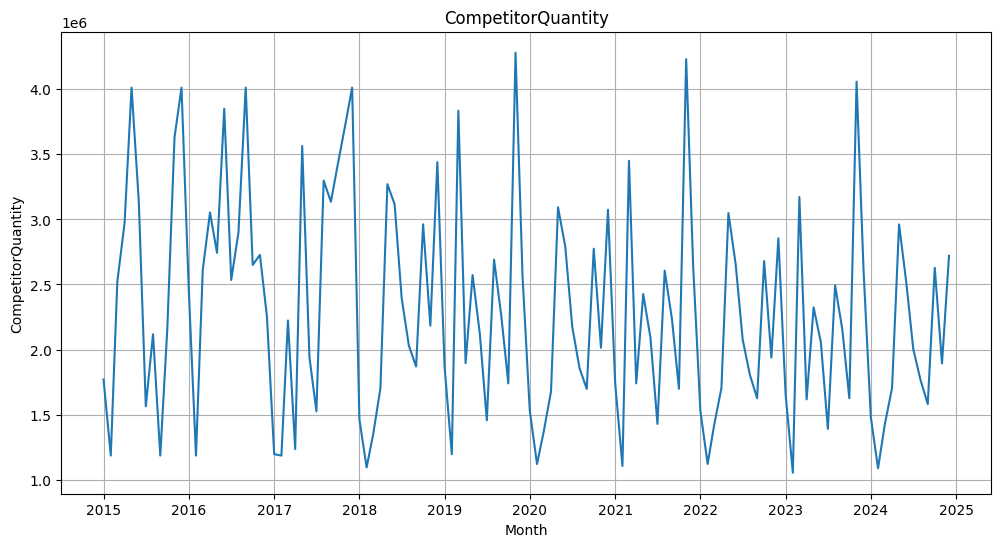

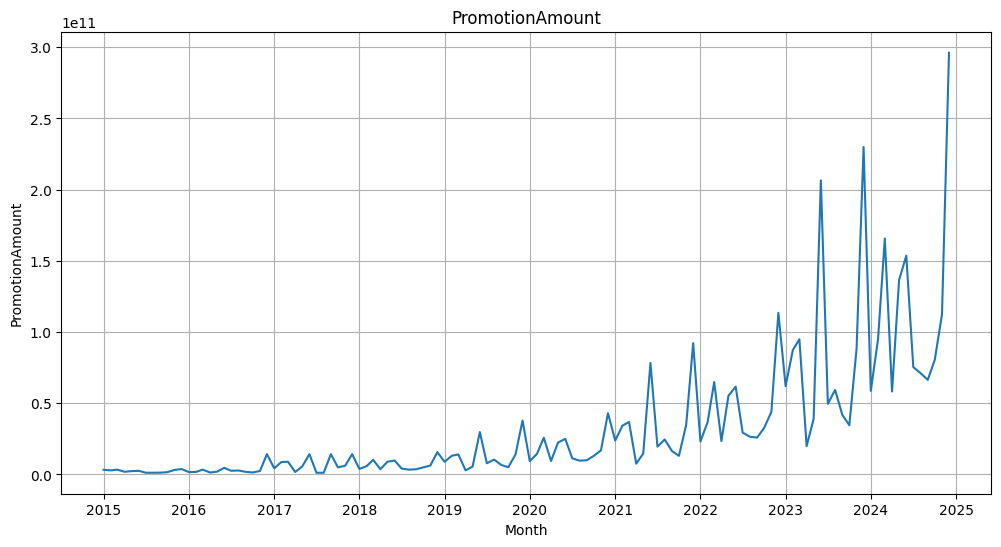

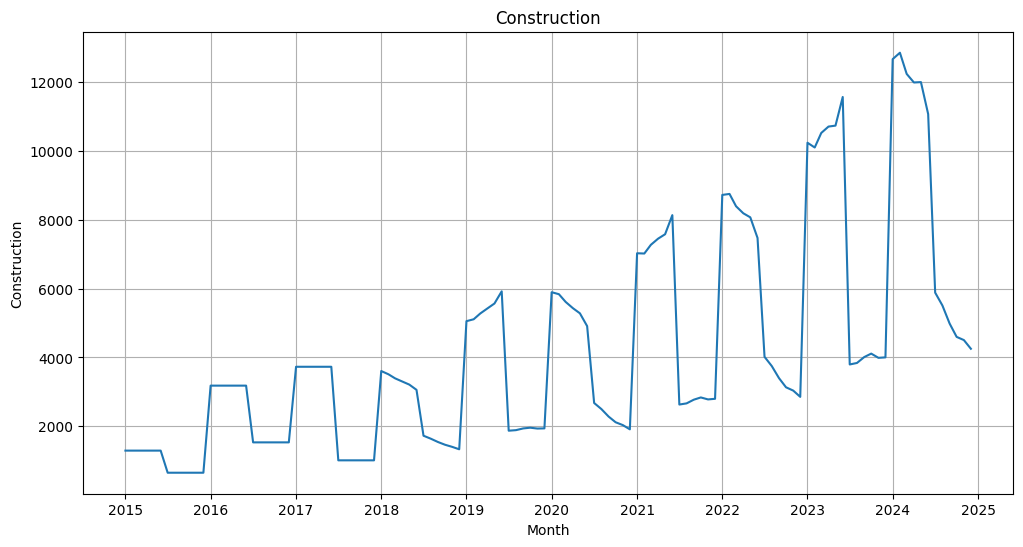

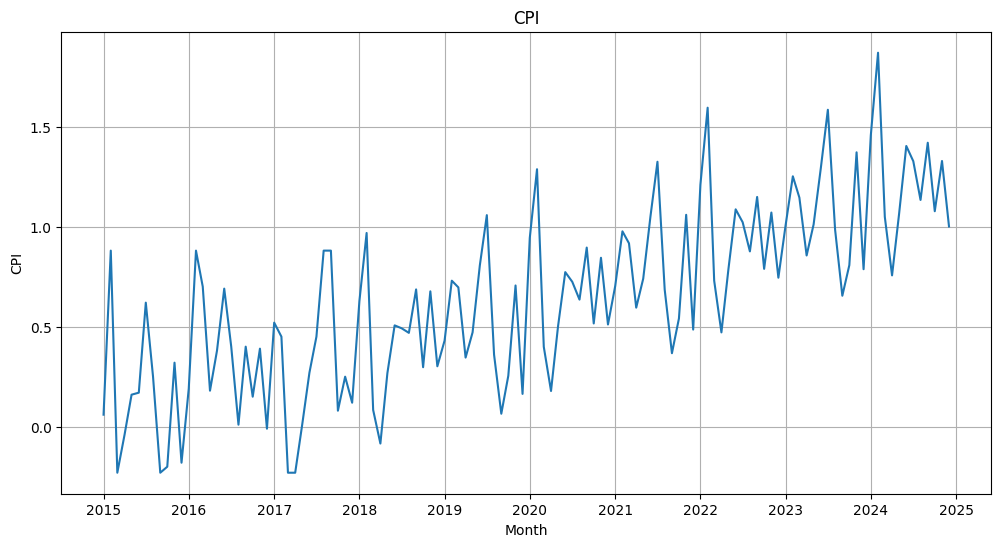

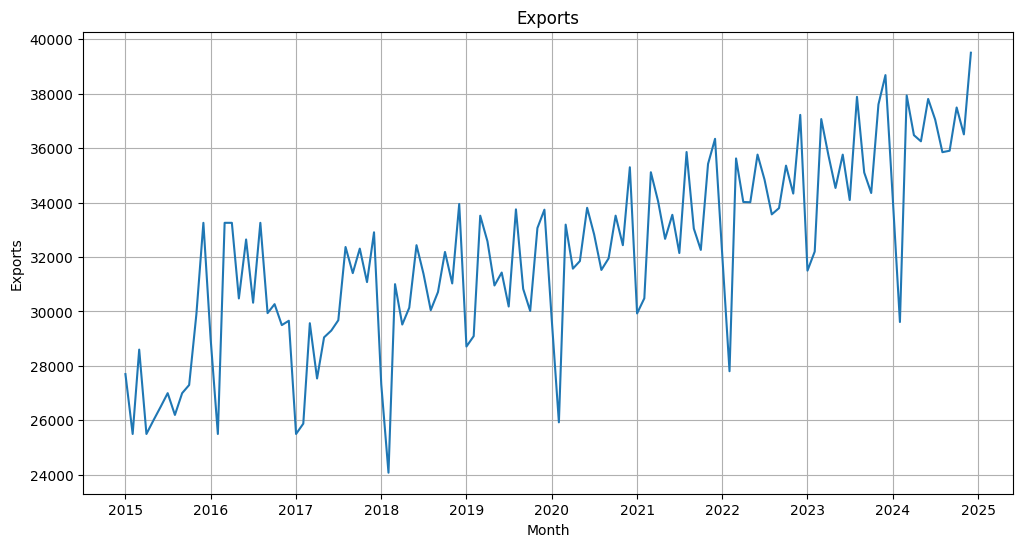

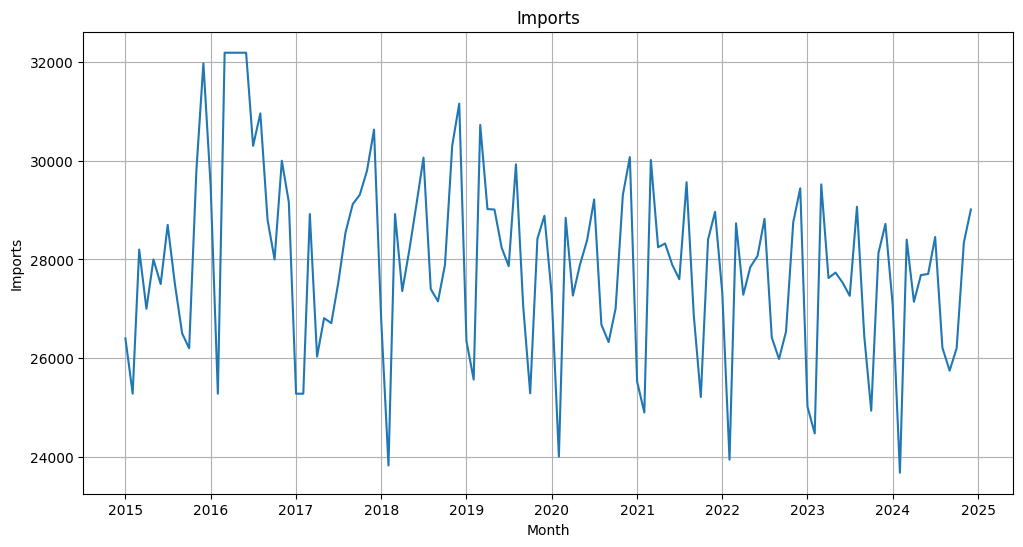

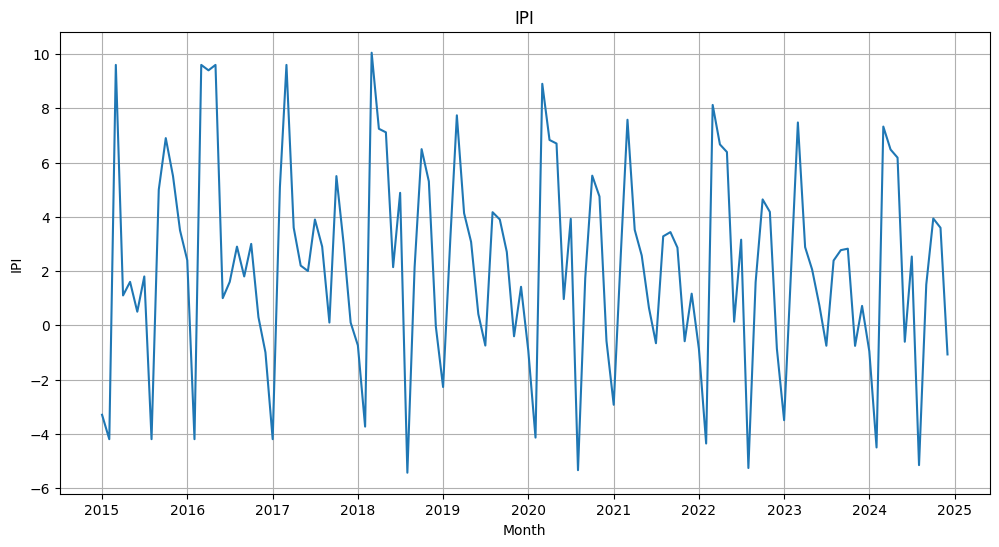

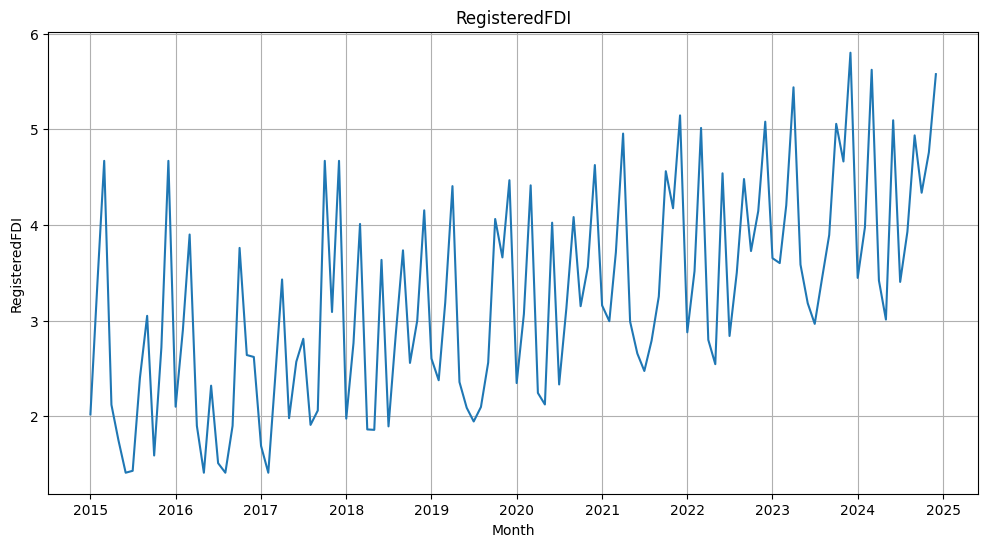

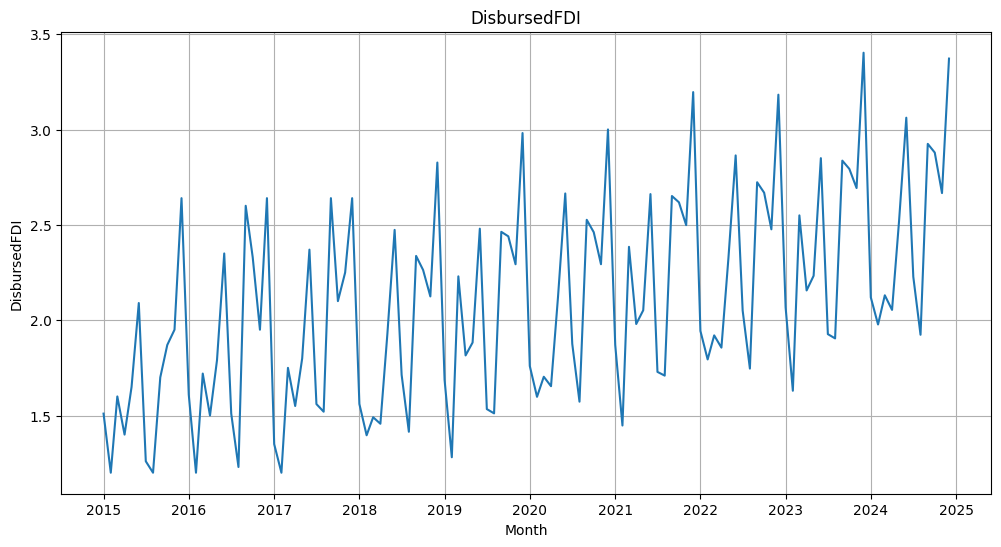

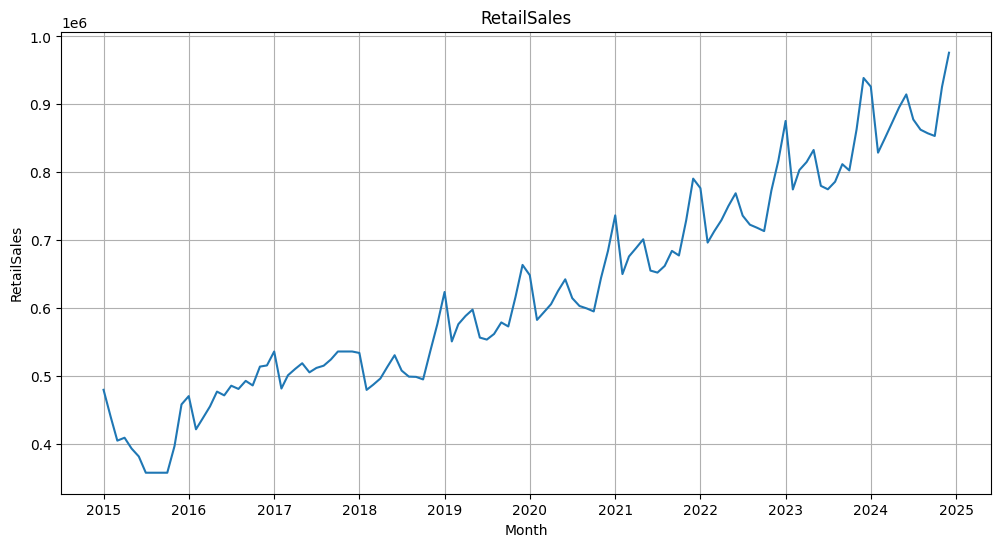

In [28]:
import matplotlib.pyplot as plt

def plot_each_column(data):

    for col in data.columns:
        if col != "Month":

            plt.figure(figsize=(12,6))

            plt.plot(data["Month"], data[col])

            plt.title(col)
            plt.xlabel("Month")
            plt.ylabel(col)

            plt.grid(True)

            plt.show()
plot_each_column(data)

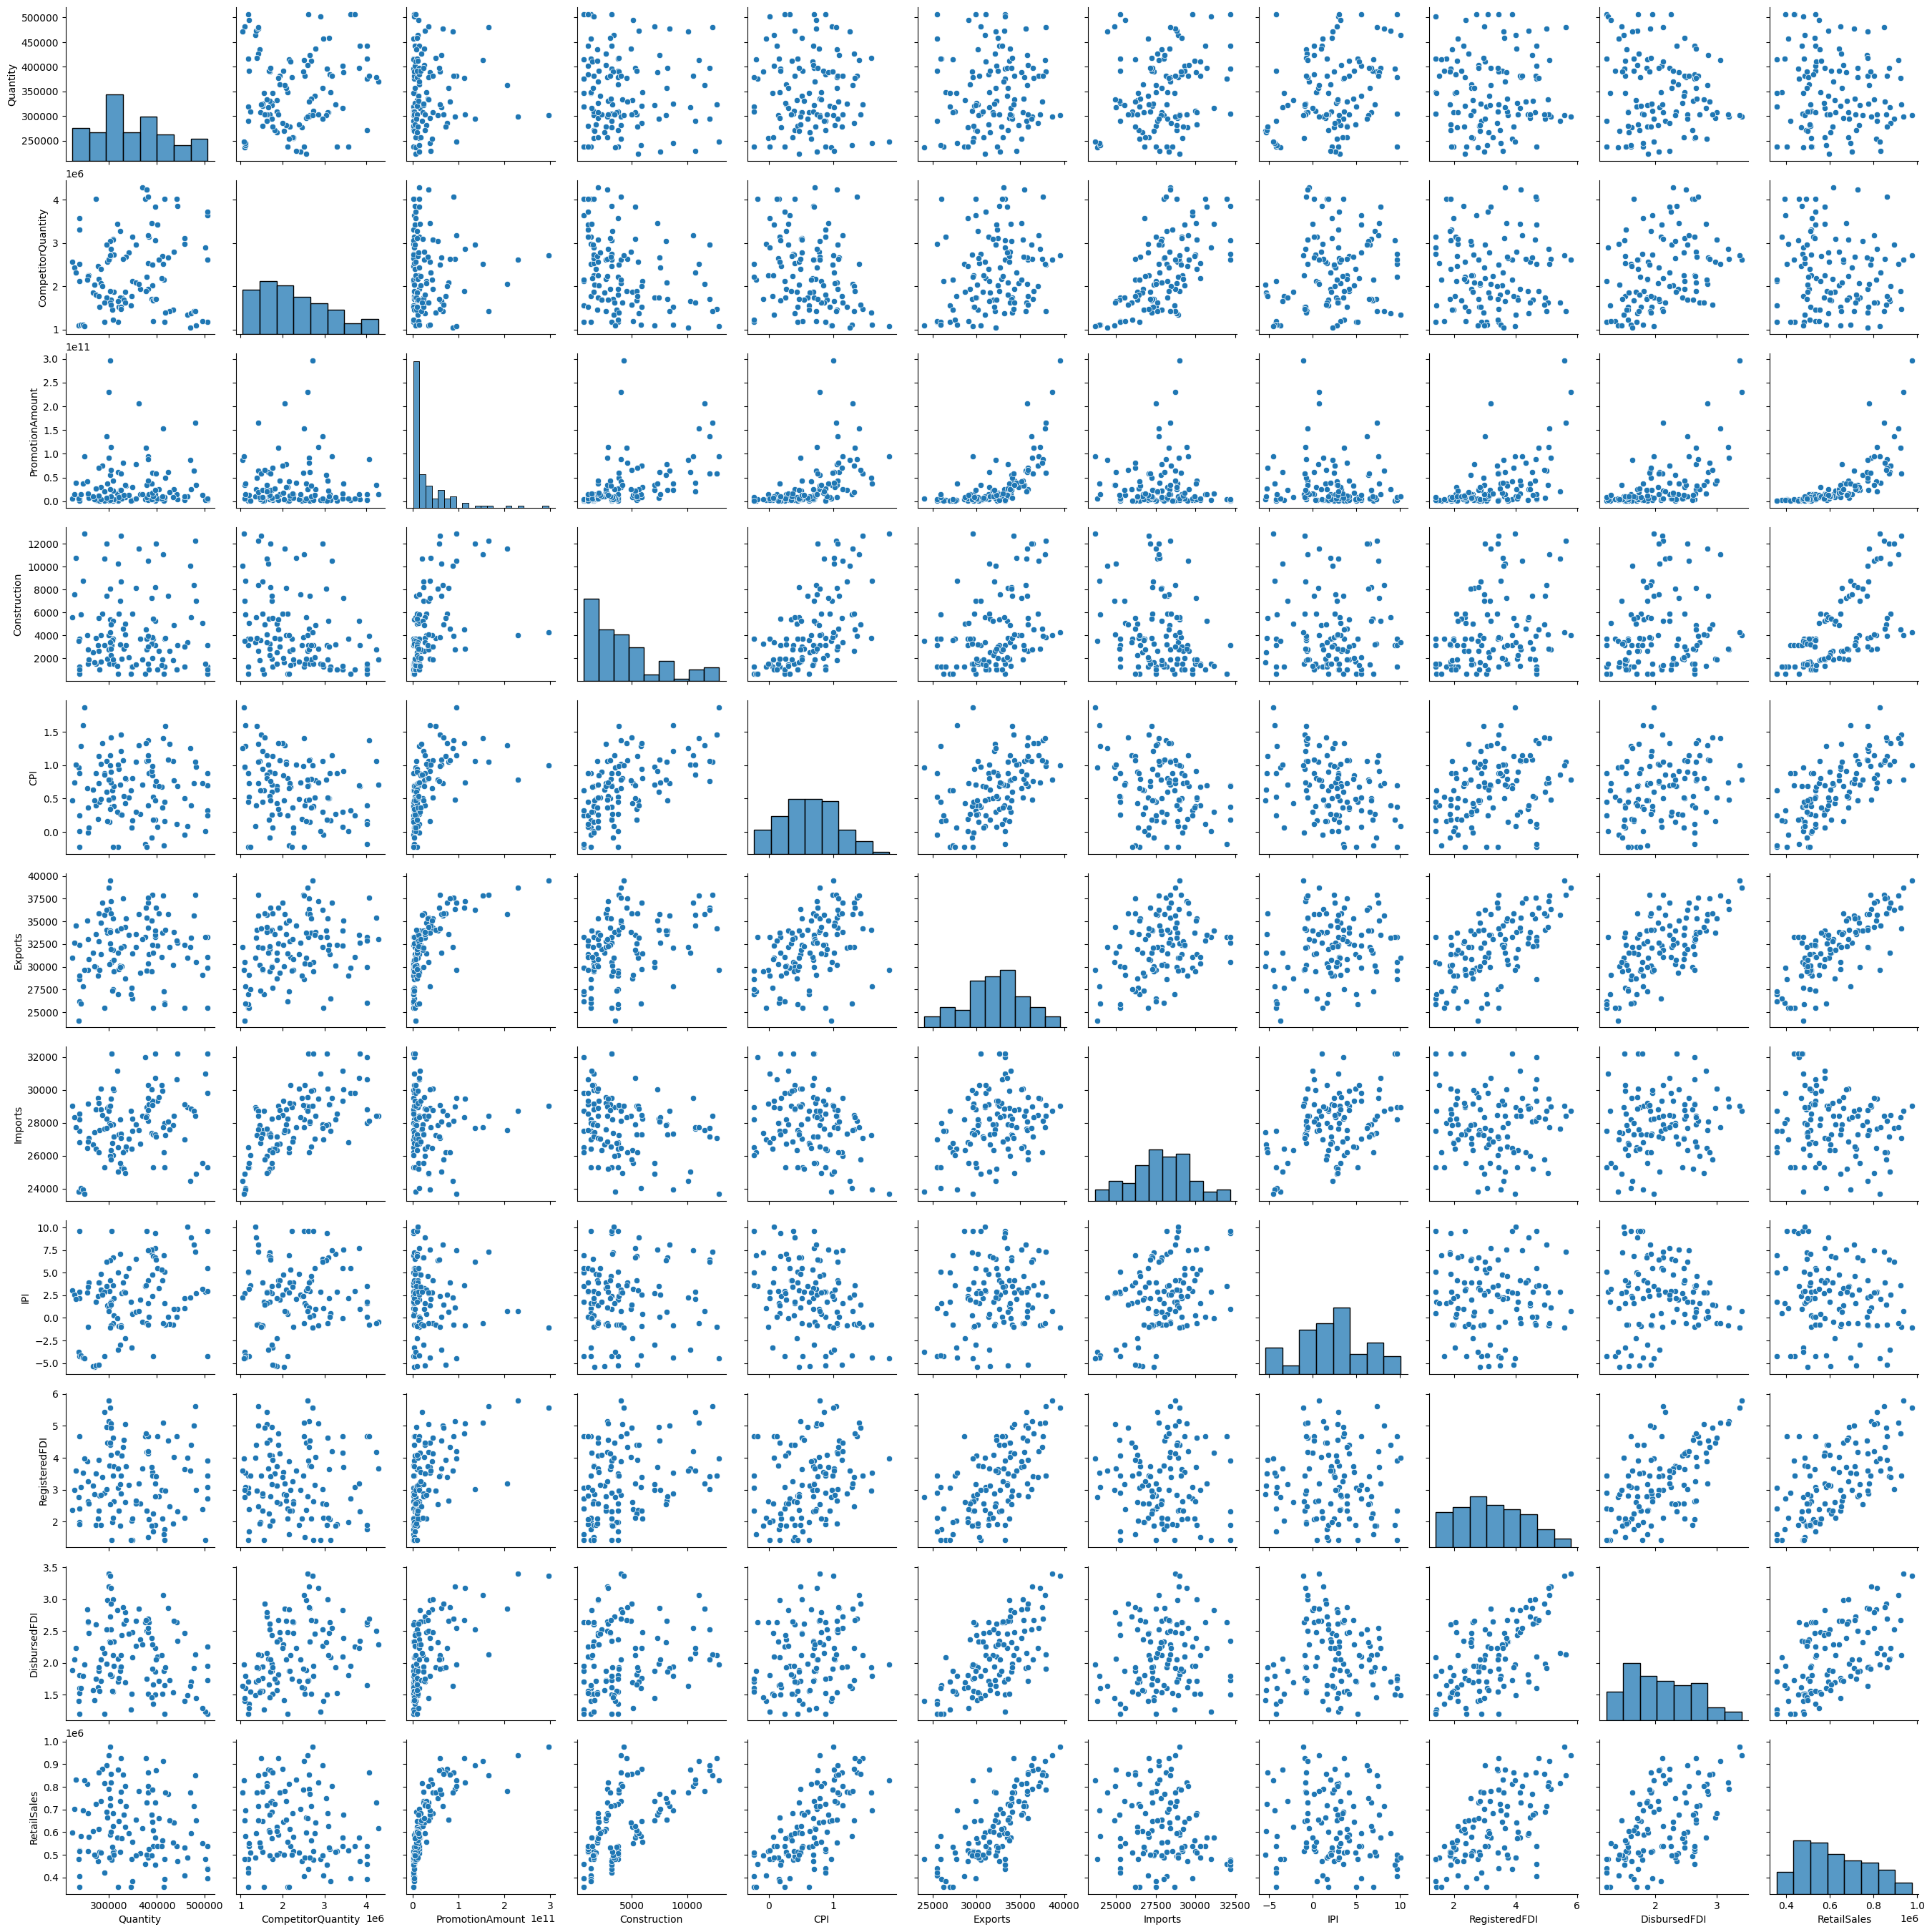

In [29]:
import seaborn as sns

sns.pairplot(data)

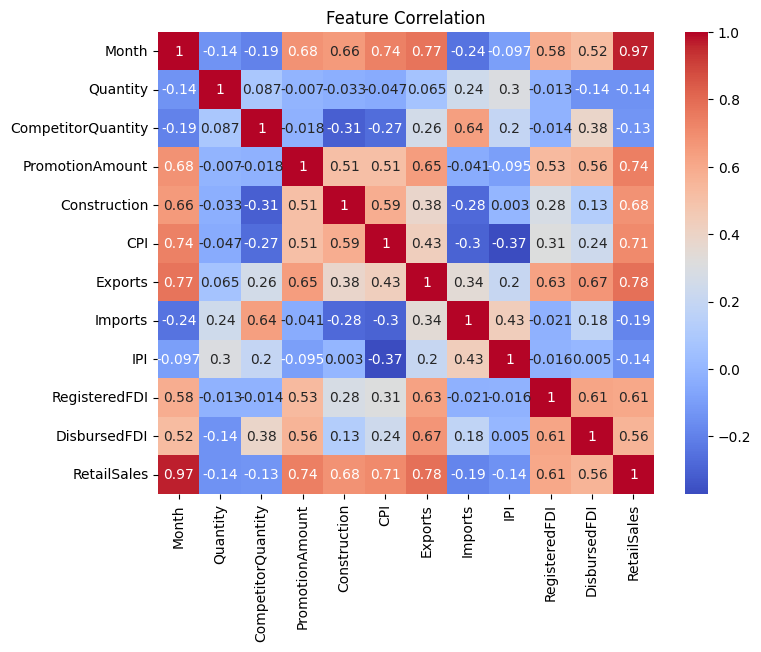

In [30]:
import seaborn as sns


def plot_correlation(df):

    plt.figure(figsize=(8,6))

    sns.heatmap(
        df.corr(),
        annot=True,
        cmap="coolwarm"
    )

    plt.title("Feature Correlation")

    plt.show()

plot_correlation(data)

# Feature Selection

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Month               120 non-null    datetime64[ns]
 1   Quantity            120 non-null    int64         
 2   CompetitorQuantity  120 non-null    float64       
 3   PromotionAmount     120 non-null    float64       
 4   Construction        120 non-null    float64       
 5   CPI                 120 non-null    float64       
 6   Exports             120 non-null    float64       
 7   Imports             120 non-null    float64       
 8   IPI                 120 non-null    float64       
 9   RegisteredFDI       120 non-null    float64       
 10  DisbursedFDI        120 non-null    float64       
 11  RetailSales         120 non-null    float64       
dtypes: datetime64[ns](1), float64(10), int64(1)
memory usage: 11.4 KB


In [40]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

X = data.drop("Quantity", axis=1)
y = data["Quantity"]

X["Month_num"] = X["Month"].dt.month

# cyclical encoding
X["Month_sin"] = np.sin(2 * np.pi * X["Month_num"] / 12)
X["Month_cos"] = np.cos(2 * np.pi * X["Month_num"] / 12)

X = X.drop(["Month", "Month_num"], axis=1)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X, y)

importance_rf = rf.feature_importances_

rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance_rf
}).sort_values("importance", ascending=False)

print(rf_importance)

               feature  importance
0   CompetitorQuantity    0.192039
6                  IPI    0.150533
5              Imports    0.136823
11           Month_cos    0.104747
8         DisbursedFDI    0.078141
7        RegisteredFDI    0.059360
10           Month_sin    0.055735
1      PromotionAmount    0.054354
4              Exports    0.048117
3                  CPI    0.044859
9          RetailSales    0.039437
2         Construction    0.035854


In [41]:
#XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X, y)
importance_xgb = xgb.feature_importances_

xgb_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance_xgb
}).sort_values("importance", ascending=False)

print(xgb_importance)

               feature  importance
5              Imports    0.240443
11           Month_cos    0.195908
6                  IPI    0.176720
1      PromotionAmount    0.075155
0   CompetitorQuantity    0.074870
10           Month_sin    0.049804
8         DisbursedFDI    0.045176
4              Exports    0.038056
7        RegisteredFDI    0.031695
3                  CPI    0.031117
2         Construction    0.022169
9          RetailSales    0.018887
